# Case Study 2 — Report 7 (Test 3)

**DEAP training-time augmentation for cross-dataset transfer**

Student: Sanjeev Veeramani (Matr. 100004303)
Supervisor: Prof. Dr. Binh Vu

---

**Objective.** Improve cross-dataset SEED accuracy by applying augmentation to DEAP DE features during training. Forces the model to learn features that are robust to noise and channel dropout, which may transfer better to SEED.

**Method:**
1. Apply three augmentations to DEAP training samples every batch:
   - **Channel dropout:** randomly zero out 3–5 of the 32 channels
   - **Gaussian noise:** add small noise to DE values (σ=0.1)
   - **Feature scaling jitter:** multiply each feature by a small random factor
2. Same architecture as Test 1/2 (CNN-LSTM+Attention + MMD)
3. Single seed (seed=42) — isolated to measure augmentation effect only
4. Compare Test 3 (augmented) vs Test 1 (no augmentation)

**Zero-shot compliance:** ✅ Augmentation is applied to DEAP only. No SEED access during training.

**Configurations:**
- Model: CNN-LSTM+Attention + MMD (R4B best)
- Mappings: binary (Neg vs Pos), 3-class
- Protocols: per-trial, per-window
- Grid: 2 mappings × 2 protocols = 4 model trainings

**Expected runtime:** ~1 hour on L4 GPU.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/case_study_2'
assert os.path.isdir(PROJECT_ROOT)

Mounted at /content/drive


In [2]:
import torch, numpy as np, pandas as pd, time, gc, pickle
from pathlib import Path

import torch.nn as nn
import torch.nn.functional as F

from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, precision_score, recall_score,
                             confusion_matrix)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: NVIDIA L4


## 2. Configuration

In [3]:
CONFIG = {
    # DEAP
    'deap_de_perwindow':  'processed/X_deap_DE_zscored.npy',
    'deap_subj_ids':      'processed/deap_subject_ids.npy',
    'deap_val_bin':       'processed/y_deap_valence.npy',
    'deap_val_3c':        'processed/y_deap_3class.npy',

    # SEED
    'seed_de_perwindow':  'processed/X_seed_DE_zscored.npy',
    'seed_subj_ids':      'processed/seed_subject_ids.npy',
    'seed_labels':        'processed/y_seed.npy',
    'seed_de_pertrial':      'processed/X_seed_DE_pertrial.npy',
    'seed_subj_ids_pertrial':'processed/subj_seed_pertrial.npy',
    'seed_labels_pertrial':  'processed/y_seed_pertrial.npy',

    'deap_n_subjects':    32,
    'deap_n_trials':      40,

    'results_dir':  'results/report7_test3_augmentation',

    'lr':            1e-3,
    'weight_decay':  1e-4,
    'mmd_lambda':    0.1,

    # Augmentation hyperparameters
    'aug_channel_dropout_p':  0.5,   # probability of applying channel dropout per batch
    'aug_channel_dropout_min':  3,   # min number of channels to zero
    'aug_channel_dropout_max':  5,   # max number of channels to zero
    'aug_noise_p':            0.5,   # probability of applying gaussian noise
    'aug_noise_std':          0.1,   # std of gaussian noise (on z-scored features)
    'aug_scale_jitter_p':     0.5,   # probability of applying scale jitter
    'aug_scale_jitter_range': 0.1,   # ±10% multiplicative jitter
}

RESULTS_DIR = Path(PROJECT_ROOT) / CONFIG['results_dir']
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'Results dir: {RESULTS_DIR}')

Results dir: /content/drive/MyDrive/case_study_2/results/report7_test3_augmentation


## 3. Load DEAP + SEED

In [4]:
root = Path(PROJECT_ROOT)

# DEAP
X_deap_pw  = np.load(root / CONFIG['deap_de_perwindow']).astype(np.float32)
subj_deap  = np.load(root / CONFIG['deap_subj_ids']).astype(np.int64)
y_deap_bin = np.load(root / CONFIG['deap_val_bin']).astype(np.int64)
y_deap_3c  = np.load(root / CONFIG['deap_val_3c']).astype(np.int64)

n_sub_d, n_tr_d = CONFIG['deap_n_subjects'], CONFIG['deap_n_trials']
n_win_d = X_deap_pw.shape[0] // (n_sub_d * n_tr_d)
X_deap_pt = X_deap_pw.reshape(n_sub_d, n_tr_d, n_win_d, -1).mean(axis=2).reshape(-1, X_deap_pw.shape[-1])
y_deap_bin_pt = y_deap_bin.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
y_deap_3c_pt  = y_deap_3c.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
subj_deap_pt = np.repeat(np.arange(1, n_sub_d + 1), n_tr_d).astype(np.int64)
print(f'DEAP per-window: {X_deap_pw.shape}, per-trial: {X_deap_pt.shape}')

# SEED per-window
X_seed_pw = np.load(root / CONFIG['seed_de_perwindow']).astype(np.float32)
subj_seed = np.load(root / CONFIG['seed_subj_ids']).astype(np.int64)
y_seed    = np.load(root / CONFIG['seed_labels']).astype(np.int64)

# SEED per-trial (from local preprocessing)
X_seed_pt    = np.load(root / CONFIG['seed_de_pertrial']).astype(np.float32)
subj_seed_pt = np.load(root / CONFIG['seed_subj_ids_pertrial']).astype(np.int64)
y_seed_pt    = np.load(root / CONFIG['seed_labels_pertrial']).astype(np.int64)
print(f'SEED per-window: {X_seed_pw.shape}, per-trial: {X_seed_pt.shape}')

DEAP per-window: (152320, 160), per-trial: (1280, 160)
SEED per-window: (304785, 160), per-trial: (675, 160)


## 4. Label mapping

In [5]:
def map_seed_to_binary(X, y, subj):
    mask = (y == 0) | (y == 2)
    return X[mask], (y[mask] == 2).astype(np.int64), subj[mask]

def map_seed_to_3class(X, y, subj):
    return X, y.astype(np.int64), subj

TEST_SETS = {}
TEST_SETS[('binary', 'per_trial')]  = map_seed_to_binary(X_seed_pt, y_seed_pt, subj_seed_pt)
TEST_SETS[('3class', 'per_trial')]  = map_seed_to_3class(X_seed_pt, y_seed_pt, subj_seed_pt)
TEST_SETS[('binary', 'per_window')] = map_seed_to_binary(X_seed_pw, y_seed, subj_seed)
TEST_SETS[('3class', 'per_window')] = map_seed_to_3class(X_seed_pw, y_seed, subj_seed)

for k, v in TEST_SETS.items():
    print(f'{k}: X {v[0].shape}, class counts {np.bincount(v[1]).tolist()}')

('binary', 'per_trial'): X (450, 160), class counts [225, 225]
('3class', 'per_trial'): X (675, 160), class counts [225, 225, 225]
('binary', 'per_window'): X (205650, 160), class counts [100575, 105075]
('3class', 'per_window'): X (304785, 160), class counts [100575, 99135, 105075]


## 5. Augmentation functions

Applied per batch during training. Each augmentation fires with probability `p` (independent).

**Channel dropout:** DE features are shape `(B, 160)` = `(B, 32 channels × 5 bands)`. Reshape to `(B, 32, 5)`, zero out `k ~ Uniform(3, 5)` random channels for each sample, then flatten back.

**Gaussian noise:** Add `N(0, 0.1)` noise. Since features are z-scored, this is ~10% of typical feature scale.

**Feature scale jitter:** Multiply each of the 160 features by `1 + Uniform(-0.1, +0.1)`. Simulates small amplitude variations.

In [6]:
def augment_batch(x, cfg):
    """Apply augmentations to a batch tensor of shape (B, 160)."""
    b = x.size(0)
    x = x.clone()   # don't mutate original

    # 1. Channel dropout
    if torch.rand(1).item() < cfg['aug_channel_dropout_p']:
        x_reshaped = x.view(b, 32, 5)
        k_min, k_max = cfg['aug_channel_dropout_min'], cfg['aug_channel_dropout_max']
        for i in range(b):
            k = torch.randint(k_min, k_max + 1, (1,)).item()
            channels_to_drop = torch.randperm(32, device=x.device)[:k]
            x_reshaped[i, channels_to_drop, :] = 0.0
        x = x_reshaped.view(b, 160)

    # 2. Gaussian noise
    if torch.rand(1).item() < cfg['aug_noise_p']:
        noise = torch.randn_like(x) * cfg['aug_noise_std']
        x = x + noise

    # 3. Scale jitter
    if torch.rand(1).item() < cfg['aug_scale_jitter_p']:
        r = cfg['aug_scale_jitter_range']
        jitter = 1.0 + (torch.rand_like(x) * 2 - 1) * r   # in [1-r, 1+r]
        x = x * jitter

    return x

## 6. Model — CNN-LSTM+Attention (same as Test 1 R4B)

In [7]:
EMBED_DIM = 128

class AttentionPool(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(in_dim, hidden), nn.Tanh(),
                                   nn.Linear(hidden, 1))
    def forward(self, x):
        w = self.score(x).squeeze(-1)
        w = torch.softmax(w, dim=1).unsqueeze(-1)
        return (x * w).sum(dim=1)

class CNNLSTMAttentionExtractor(nn.Module):
    def __init__(self, n_bands=5, embed=EMBED_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_bands, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=False)
        self.attn = AttentionPool(128, hidden=64)
        self.fc = nn.Sequential(nn.Linear(128, embed), nn.ReLU(), nn.Dropout(0.3))
    def forward(self, x):
        b = x.size(0)
        x = x.view(b, 32, 5)
        x = x.transpose(1, 2)
        x = self.conv(x)
        x = x.transpose(1, 2)
        h, _ = self.lstm(x)
        return self.fc(self.attn(h))

class EmotionModel(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.extractor  = CNNLSTMAttentionExtractor()
        self.head = nn.Sequential(
            nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
    def forward(self, x, return_features=False):
        feat = self.extractor(x)
        logits = self.head(feat)
        if return_features:
            return logits, feat
        return logits

def linear_mmd_by_subject(features, subject_ids):
    unique = torch.unique(subject_ids)
    if len(unique) < 2:
        return torch.tensor(0.0, device=features.device)
    means = [features[subject_ids == s].mean(dim=0)
             for s in unique if (subject_ids == s).sum() > 0]
    means = torch.stack(means)
    diffs = means.unsqueeze(0) - means.unsqueeze(1)
    sq = (diffs * diffs).sum(dim=-1)
    n = len(unique)
    return sq.sum() / max(n * (n - 1), 1)

## 7. Train with augmentation

In [8]:
def train_with_augmentation(X_train_np, y_train_np, subj_train_np,
                            X_test_np, y_test_np,
                            n_classes, epochs, batch_size, lr, wd, mmd_lambda,
                            aug_cfg):
    """Train on DEAP with augmentation, evaluate on SEED."""
    X_tr = torch.from_numpy(X_train_np).to(DEVICE)
    y_tr = torch.from_numpy(y_train_np).long().to(DEVICE)
    s_tr = torch.from_numpy(subj_train_np).long().to(DEVICE)
    X_te = torch.from_numpy(X_test_np).to(DEVICE)

    unique_s = torch.unique(s_tr)
    remap = torch.zeros(int(unique_s.max()) + 1, dtype=torch.long, device=DEVICE)
    remap[unique_s] = torch.arange(unique_s.size(0), device=DEVICE)
    s_tr_remap = remap[s_tr]

    model = EmotionModel(n_classes).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    counts = np.bincount(y_train_np, minlength=n_classes)
    w = 1.0 / (counts + 1e-10); w = w / w.sum() * n_classes
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))

    best_bal, best_preds, best_epoch = -1.0, None, 0
    n = X_tr.size(0)

    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            if idx.size(0) < 2: continue
            xb = X_tr[idx]
            yb, sb = y_tr[idx], s_tr_remap[idx]

            # >>> Augmentation applied here <<<
            xb_aug = augment_batch(xb, aug_cfg)

            opt.zero_grad()
            logits, feat = model(xb_aug, return_features=True)
            loss = loss_fn(logits, yb) + mmd_lambda * linear_mmd_by_subject(feat, sb)
            loss.backward()
            opt.step()
        sched.step()

        # Evaluate on SEED (no augmentation at test time)
        model.eval()
        with torch.no_grad():
            preds = []
            for i in range(0, X_te.size(0), batch_size*2):
                preds.append(model(X_te[i:i+batch_size*2]).argmax(dim=1))
            y_pred = torch.cat(preds).cpu().numpy()
        bal = balanced_accuracy_score(y_test_np, y_pred)
        if bal > best_bal:
            best_bal, best_epoch = bal, ep
            best_preds = y_pred.copy()

    return best_preds, best_bal, best_epoch

## 8. Main loop — 4 configurations with augmentation

In [9]:
def get_deap_train_set(mapping, protocol):
    if protocol == 'per_trial':
        X = X_deap_pt; subj = subj_deap_pt
        y = y_deap_bin_pt if mapping == 'binary' else y_deap_3c_pt
    else:
        X = X_deap_pw; subj = subj_deap
        y = y_deap_bin if mapping == 'binary' else y_deap_3c
    return X.astype(np.float32), y.astype(np.int64), subj.astype(np.int64)

ALL_RESULTS = {}

for (mapping, protocol), (X_test, y_test, s_test) in TEST_SETS.items():
    key = (mapping, protocol)
    print(f'\n{"="*60}\n{mapping} × {protocol}\n{"="*60}')

    X_train, y_train, subj_train = get_deap_train_set(mapping, protocol)
    n_classes = 3 if mapping == '3class' else 2
    batch = 512 if protocol == 'per_window' else 128
    epochs = 20 if protocol == 'per_window' else 40

    t0 = time.time()
    y_pred, best_bal, best_ep = train_with_augmentation(
        X_train, y_train, subj_train, X_test, y_test,
        n_classes=n_classes, epochs=epochs, batch_size=batch,
        lr=CONFIG['lr'], wd=CONFIG['weight_decay'], mmd_lambda=CONFIG['mmd_lambda'],
        aug_cfg=CONFIG)
    elapsed = time.time() - t0

    print(f'  best SEED bal={100*best_bal:.2f}% at epoch {best_ep+1}  time={elapsed:.1f}s')

    ALL_RESULTS[key] = {
        'y_true': y_test, 'y_pred': y_pred,
        'best_bal': best_bal, 'best_epoch': best_ep,
        'n_test': len(y_test),
    }

    del X_train, y_train, subj_train
    gc.collect()
    if torch.cuda.is_available(): torch.cuda.empty_cache()


binary × per_trial
  best SEED bal=65.56% at epoch 4  time=22.7s

3class × per_trial
  best SEED bal=48.89% at epoch 9  time=11.8s

binary × per_window
  best SEED bal=66.62% at epoch 1  time=332.7s

3class × per_window
  best SEED bal=46.06% at epoch 2  time=342.9s


## 9. Aggregate + save

In [10]:
rows = []
for (mapping, protocol), r in ALL_RESULTS.items():
    y_true, y_pred = r['y_true'], r['y_pred']
    n_classes = 3 if mapping == '3class' else 2
    chance = 100.0 / n_classes
    rows.append({
        'mapping': mapping, 'protocol': protocol,
        'accuracy':     100 * accuracy_score(y_true, y_pred),
        'bal_accuracy': 100 * balanced_accuracy_score(y_true, y_pred),
        'f1_weighted':  100 * f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'precision_macro': 100 * precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall_macro':    100 * recall_score(y_true, y_pred, average='macro', zero_division=0),
        'chance':          chance,
        'gap_from_chance': 100 * r['best_bal'] - chance,
        'n_test':          len(y_true),
    })

SUMMARY = pd.DataFrame(rows)
SUMMARY.to_csv(RESULTS_DIR / 'summary_test3_augmentation.csv', index=False)
print(SUMMARY.to_string(index=False))

mapping   protocol  accuracy  bal_accuracy  f1_weighted  precision_macro  recall_macro    chance  gap_from_chance  n_test
 binary  per_trial 65.555556     65.555556    64.153377        68.440895     65.555556 50.000000        15.555556     450
 3class  per_trial 48.888889     48.888889    39.165670        32.699720     48.888889 33.333333        15.555556     675
 binary per_window 66.648675     66.622809    66.644695        66.630746     66.622809 50.000000        16.622809  205650
 3class per_window 46.301819     46.061245    45.640158        46.410110     46.061245 33.333333        12.727912  304785


## 10. Test 1 vs Test 3 comparison

In [11]:
# Test 1 R4B MMD single-seed results
TEST1_R4B_MMD = {
    ('binary',  'per_trial'):  66.67,
    ('binary',  'per_window'): 66.81,
    ('3class',  'per_trial'):  46.07,
    ('3class',  'per_window'): 45.04,
}

rows_compare = []
for (mapping, protocol), r in ALL_RESULTS.items():
    t1 = TEST1_R4B_MMD.get((mapping, protocol))
    t3 = 100 * r['best_bal']
    rows_compare.append({
        'config':               f'{mapping}\n{protocol}',
        'Test 1 (no augment)':  t1,
        'Test 3 (augmented)':   t3,
        'delta':                t3 - t1,
    })

df_c = pd.DataFrame(rows_compare)
print(df_c.to_string(index=False))

            config  Test 1 (no augment)  Test 3 (augmented)     delta
 binary\nper_trial                66.67           65.555556 -1.114444
 3class\nper_trial                46.07           48.888889  2.818889
binary\nper_window                66.81           66.622809 -0.187191
3class\nper_window                45.04           46.061245  1.021245


## 11. Plots

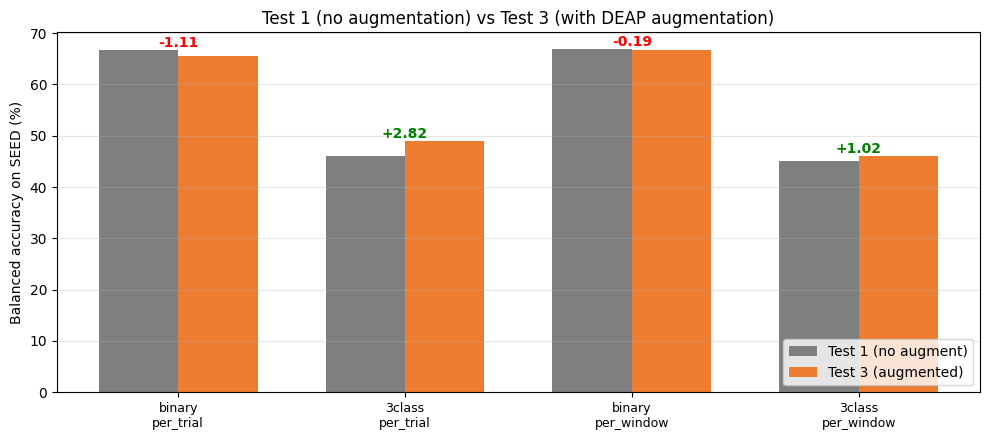

In [12]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})

PLOTS_DIR = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(10, 4.5))
x = np.arange(len(df_c)); w = 0.35
ax.bar(x - w/2, df_c['Test 1 (no augment)'], w, label='Test 1 (no augment)', color='#7f7f7f')
ax.bar(x + w/2, df_c['Test 3 (augmented)'],  w, label='Test 3 (augmented)',  color='#ED7D31')

for i, row in df_c.iterrows():
    color = 'green' if row['delta'] > 0 else 'red'
    y_top = max(row['Test 1 (no augment)'], row['Test 3 (augmented)'])
    ax.text(i, y_top + 0.6, f'{row["delta"]:+.2f}',
            ha='center', fontsize=10, color=color, fontweight='bold')

ax.set_xticks(x); ax.set_xticklabels(df_c['config'], fontsize=9)
ax.set_ylabel('Balanced accuracy on SEED (%)')
ax.set_title('Test 1 (no augmentation) vs Test 3 (with DEAP augmentation)')
ax.legend(loc='lower right')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'test3_vs_test1.png', dpi=140, bbox_inches='tight')
plt.show()

## 12. Interpretation

**Read the delta values in Section 10:**

- **Positive delta (green):** Augmentation helped that config
- **Negative delta (red):** Augmentation hurt (probably too aggressive for that config)
- **Small delta (±1 pp):** Within noise, augmentation didn't matter for that config

**Expected patterns:**
- Per-window configs may benefit more (more data → augmentation regularizes better)
- Per-trial configs may be sensitive (only 1280 training samples, augmentation can dominate)
- Binary usually more robust to augmentation than 3-class

**If augmentation clearly helps (+2 pp or more):** consider Test 4 combining augmentation + ensembling.

**If augmentation doesn't help or hurts:** it's not the right lever for this problem, and single-model or ensemble alone is better.